# Image segmentation, an introduction

### A label for every pixel, and a metric that notices when you predict nothing

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why pixel accuracy is the wrong metric for a small foreground, how IoU and Dice fix it and how they relate, how to write a U-Net from scratch, and what the skip connections are actually contributing, measured at the boundaries where they should matter most |
| **You should already know** | [08-02 A convolutional network, layer by layer](../02-a-cnn-layer-by-layer/) and [08-03 Classic architectures](../03-classic-architectures/) for the skip connection |
| **Dataset** | Synthetic 64x64 images generated in this notebook, so every ground truth mask is exact |
| **Runtime** | Two to four minutes on a laptop CPU. The device it used is printed below |
| **Next** | [08-07 Object detection](../07-object-detection/) |

---

## 1. The idea

Classification asks what is in the picture. Segmentation asks, for every pixel,
what that pixel belongs to. The output is not ten numbers, it is an image the
same size as the input with a label in every position.

Two consequences follow immediately, and they set up the whole chapter.

**The output has to come back up to full resolution.** A classifier can pool the
image down to nothing, because it only owes you one answer. A segmenter pools
down to build features that mean something, then has to get back to 64x64 with
the boundaries in the right place. Everything called an encoder-decoder is a
solution to that problem, and the U-Net is the one that stuck.

**The classes are wildly imbalanced.** In the images below the thing being
segmented occupies a small share of the pixels, and the metric that most people
reach for first cannot see the difference between a good model and a model that
outputs all background. I will show that with the number rather than assert it.

### Why synthetic data here

Real segmentation datasets come with masks a human drew, and human masks
disagree with each other at exactly the boundaries I want to measure. So this
chapter generates its own images: bright discs and bright rectangles on a noisy
background, where the task is to find **the discs only**. The mask is exact by
construction, because I drew it.

The rectangles are there on purpose. They are the same brightness as the discs,
so brightness alone cannot solve the task, and a model has to use shape. That
also gives the threshold baseline in section 5 something real to fail at.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"

SIDE = 64
N_TRAIN, N_TEST = 400, 100
BATCH = 16
EPOCHS = 20
LR = 2e-3

NOTEBOOK_STARTED = time.perf_counter()
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


### The generator

Discs are the target, rectangles are distractors, both drawn with brightness
picked from the same range. Shapes are drawn hard-edged rather than
anti-aliased, so a pixel is either inside the mask or outside it and there is no
ambiguity to argue about later.

In [2]:
def make_example(rng, side=SIDE):
    """One image and its exact mask. Discs are foreground, rectangles are not."""
    rows, cols = np.mgrid[0:side, 0:side]
    image = 0.12 + 0.04 * rng.standard_normal((side, side))
    mask = np.zeros((side, side), dtype=np.float32)

    # distractors first, so a disc drawn on top of one stays visible
    for _ in range(rng.integers(1, 4)):
        cy, cx = rng.integers(10, side - 10, size=2)
        half_h, half_w = rng.integers(4, 10), rng.integers(4, 10)
        inside = (np.abs(rows - cy) <= half_h) & (np.abs(cols - cx) <= half_w)
        image = np.where(inside, 0.55 + 0.35 * rng.random(), image)

    for _ in range(rng.integers(1, 3)):
        cy, cx = rng.integers(11, side - 11, size=2)
        radius = rng.integers(5, 11)
        inside = (rows - cy) ** 2 + (cols - cx) ** 2 <= radius ** 2
        image = np.where(inside, 0.55 + 0.35 * rng.random(), image)
        mask = np.maximum(mask, inside.astype(np.float32))

    image = image + 0.05 * rng.standard_normal((side, side))
    return np.clip(image, 0.0, 1.0).astype(np.float32), mask


def make_set(n, seed):
    rng = np.random.default_rng(seed)
    pairs = [make_example(rng) for _ in range(n)]
    images = torch.from_numpy(np.stack([p[0] for p in pairs])).unsqueeze(1)
    masks = torch.from_numpy(np.stack([p[1] for p in pairs])).unsqueeze(1)
    return images, masks


x_train, m_train = make_set(N_TRAIN, SEED)
x_test, m_test = make_set(N_TEST, SEED + 1)

foreground_train = float(m_train.mean())
foreground_test = float(m_test.mean())
print(f"train: {tuple(x_train.shape)} images, {tuple(m_train.shape)} masks")
print(f"test : {tuple(x_test.shape)} images")
print(f"foreground share: {foreground_train:.4f} of training pixels, "
      f"{foreground_test:.4f} of test pixels")
print(f"so a model that predicts background everywhere is right on "
      f"{1 - foreground_test:.2%} of test pixels")

train: (400, 1, 64, 64) images, (400, 1, 64, 64) masks
test : (100, 1, 64, 64) images
foreground share: 0.0668 of training pixels, 0.0703 of test pixels
so a model that predicts background everywhere is right on 92.97% of test pixels


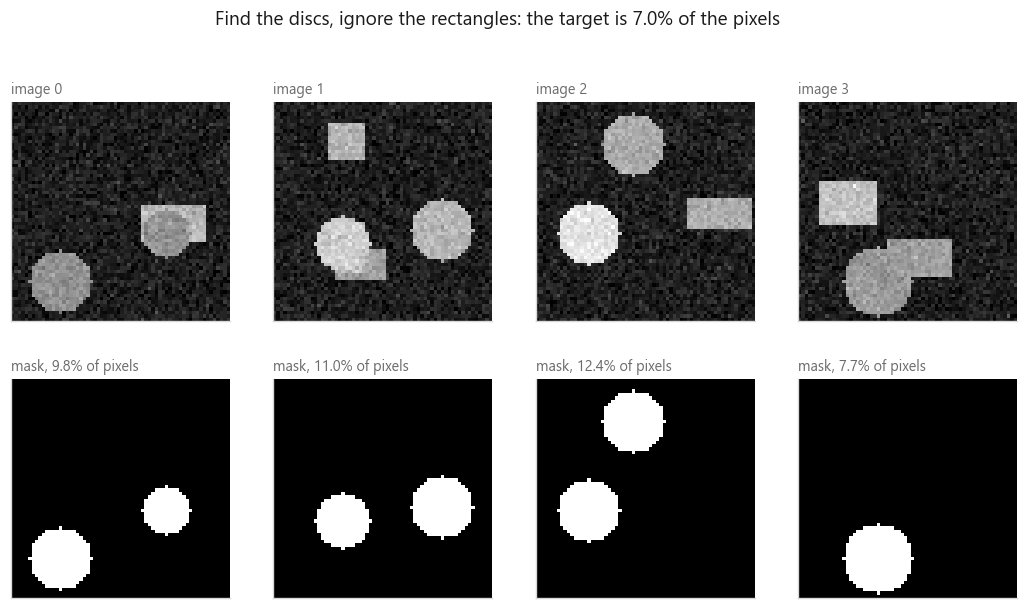

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(11.8, 6.0))
for column in range(4):
    axes[0, column].imshow(x_test[column, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, column].set_title(f"image {column}", fontsize=9.5, color=style.MUTED, loc="left")
    axes[1, column].imshow(m_test[column, 0], cmap="gray", vmin=0, vmax=1)
    share = float(m_test[column].mean())
    axes[1, column].set_title(f"mask, {share:.1%} of pixels", fontsize=9.5,
                              color=style.MUTED, loc="left")
    for row in range(2):
        axes[row, column].set_xticks([]); axes[row, column].set_yticks([])
        axes[row, column].grid(False)

fig.suptitle(f"Find the discs, ignore the rectangles: the target is "
             f"{foreground_test:.1%} of the pixels",
             x=0.5, y=1.01, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-synthetic-data.png")

## 2. The maths: three metrics that disagree

Write $P$ for the set of pixels the model calls foreground and $T$ for the set
that truly is. Count the four outcomes as $TP$, $FP$, $FN$ and $TN$.

**Pixel accuracy** is the fraction of pixels labelled correctly:

$$\text{acc} = \frac{TP + TN}{TP + TN + FP + FN}$$

The problem is the $TN$ term. When the foreground is a small share of the image,
$TN$ dwarfs everything else, and a model that outputs nothing at all collects
almost the whole numerator. The printed number above already says what such a
model scores here.

**Intersection over union**, also called the Jaccard index, throws the true
negatives away:

$$\text{IoU} = \frac{|P \cap T|}{|P \cup T|} = \frac{TP}{TP + FP + FN}$$

Predict nothing and $TP = 0$, so IoU is zero. That is the behaviour you want.

**Dice**, the same idea with the intersection counted twice:

$$\text{Dice} = \frac{2|P \cap T|}{|P| + |T|} = \frac{2TP}{2TP + FP + FN}$$

The two are monotone in each other, which is worth knowing so you stop treating
them as independent evidence:

$$\text{Dice} = \frac{2\,\text{IoU}}{1 + \text{IoU}}$$

Dice is always at least as large as IoU, so a paper reporting Dice is reporting
the more flattering of the two. The cell below checks the identity numerically
rather than asking you to take it.

## 3. From scratch: the metrics in NumPy

In [4]:
def counts(pred, true):
    """The four cells of the confusion table for two boolean arrays."""
    pred, true = pred.astype(bool), true.astype(bool)
    return {"tp": int((pred & true).sum()), "fp": int((pred & ~true).sum()),
            "fn": int((~pred & true).sum()), "tn": int((~pred & ~true).sum())}


def pixel_accuracy(pred, true):
    c = counts(pred, true)
    return (c["tp"] + c["tn"]) / sum(c.values())


def iou(pred, true):
    c = counts(pred, true)
    denominator = c["tp"] + c["fp"] + c["fn"]
    return c["tp"] / denominator if denominator else 1.0    # both empty counts as perfect


def dice(pred, true):
    c = counts(pred, true)
    denominator = 2 * c["tp"] + c["fp"] + c["fn"]
    return 2 * c["tp"] / denominator if denominator else 1.0


truth = m_test.numpy().astype(bool)

cases = {
    "predict all background": np.zeros_like(truth),
    "predict all foreground": np.ones_like(truth),
    "the true mask": truth.copy(),
    "the true mask, shifted 2 pixels": np.roll(truth, 2, axis=2),
}

rows = []
for name, prediction in cases.items():
    rows.append({"prediction": name,
                 "pixel accuracy": pixel_accuracy(prediction, truth),
                 "IoU": iou(prediction, truth),
                 "Dice": dice(prediction, truth)})

metric_demo = pd.DataFrame(rows)
metric_demo["Dice from IoU"] = 2 * metric_demo["IoU"] / (1 + metric_demo["IoU"])
print(metric_demo.to_string(index=False, float_format="{:.4f}".format))
print(f"\nlargest gap between Dice and the identity 2*IoU/(1+IoU): "
      f"{(metric_demo['Dice'] - metric_demo['Dice from IoU']).abs().max():.2e}")

                     prediction  pixel accuracy    IoU   Dice  Dice from IoU
         predict all background          0.9297 0.0000 0.0000         0.0000
         predict all foreground          0.0703 0.0703 0.1314         0.1314
                  the true mask          1.0000 1.0000 1.0000         1.0000
the true mask, shifted 2 pixels          0.9780 0.7294 0.8436         0.8436

largest gap between Dice and the identity 2*IoU/(1+IoU): 0.00e+00


The first row is the whole argument. A model that has learned nothing, predicts
nothing and would be useless in any application scores a pixel accuracy most
people would be pleased to report, and an IoU of zero. Anyone who reports pixel
accuracy on an imbalanced segmentation problem is reporting the class prior.

The last row is the second lesson. Shifting the correct mask by two pixels
leaves pixel accuracy nearly untouched while IoU falls, because IoU only ever
looks at the small set of pixels either mask claims. The metrics that ignore the
background are also the metrics that notice the boundary, and that is why
section 5 can measure what the skip connections do.

### The boundary band

One more measurement, defined here so section 5 can use it. Dilate the true mask
and erode it, and the difference is a band of pixels straddling the boundary.
Scoring inside that band only is a harder question than scoring the whole image,
because it deletes the easy interior and the easy far background.

In [5]:
def boundary_band(masks, width=2):
    """Pixels within `width` of a mask edge, as a boolean tensor.

    Max pooling is dilation. Max pooling the negative is erosion. The difference
    is the band, and no morphology library is needed for either.
    """
    kernel = 2 * width + 1
    dilated = F.max_pool2d(masks, kernel, stride=1, padding=width)
    eroded = -F.max_pool2d(-masks, kernel, stride=1, padding=width)
    return (dilated - eroded) > 0.5


band = boundary_band(m_test)
print(f"boundary band covers {float(band.float().mean()):.4f} of test pixels, "
      f"against a foreground share of {foreground_test:.4f}")
print(f"inside the band, {float(m_test[band].mean()):.3f} of pixels are foreground, "
      f"against {foreground_test:.3f} over the whole image, so the band is the "
      f"far less imbalanced place to score")

boundary band covers 0.0894 of test pixels, against a foreground share of 0.0703
inside the band, 0.415 of pixels are foreground, against 0.070 over the whole image, so the band is the far less imbalanced place to score


## 4. In practice: a U-Net

The shape is an encoder that halves resolution while doubling channels, a
bottleneck, and a decoder that reverses it. What makes it a U-Net rather than an
autoencoder is the horizontal wiring: the decoder is handed the encoder's
feature map at the matching resolution, concatenated onto its own.

The reason is a division of labour. The bottleneck knows *what* is in the image,
because it has seen a large receptive field, but it has thrown away *where* to
two levels of pooling. The encoder's early feature maps know exactly where every
edge is and very little about what it belongs to. The skip hands the second to
the first.

### How the control is built

To measure that claim, the network below takes a `use_skips` flag. When it is
off, the concatenation still happens, but with a block of zeros in place of the
encoder features. Both versions therefore have **identical parameter counts and
identical arithmetic cost**, and the only difference is whether the skip carries
anything. Cutting the concatenation instead would have made the second network
smaller, and the comparison would have confounded skips with capacity.

In [6]:
def double_conv(in_ch, out_ch):
    """The U-Net's repeated unit: two 3x3 convolutions, each normalised and rectified."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(),
        nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(),
    )


class UNet(nn.Module):
    """Two down, bottleneck, two up. One logit per pixel."""

    def __init__(self, width=16, use_skips=True):
        super().__init__()
        self.use_skips = use_skips
        c = width
        self.enc1 = double_conv(1, c)
        self.enc2 = double_conv(c, 2 * c)
        self.bottleneck = double_conv(2 * c, 4 * c)
        self.up2 = nn.ConvTranspose2d(4 * c, 2 * c, 2, stride=2)
        self.dec2 = double_conv(4 * c, 2 * c)
        self.up1 = nn.ConvTranspose2d(2 * c, c, 2, stride=2)
        self.dec1 = double_conv(2 * c, c)
        self.head = nn.Conv2d(c, 1, 1)

    def join(self, upsampled, skip):
        # zeros rather than the encoder map when skips are off, so the shapes and
        # the parameter count stay exactly the same
        return torch.cat([upsampled, skip if self.use_skips else torch.zeros_like(skip)], dim=1)

    def forward(self, x):
        e1 = self.enc1(x)                              # 64x64
        e2 = self.enc2(F.max_pool2d(e1, 2))            # 32x32
        b = self.bottleneck(F.max_pool2d(e2, 2))       # 16x16
        d2 = self.dec2(self.join(self.up2(b), e2))     # 32x32
        d1 = self.dec1(self.join(self.up1(d2), e1))    # 64x64
        return self.head(d1)


count = lambda m: sum(p.numel() for p in m.parameters())
print(f"with skips    : {count(UNet(use_skips=True)):,} parameters")
print(f"without skips : {count(UNet(use_skips=False)):,} parameters")
print(f"identical: "
      f"{count(UNet(use_skips=True)) == count(UNet(use_skips=False))}")

with skips    : 117,073 parameters
without skips : 117,073 parameters
identical: True


### Training

Per-pixel binary cross entropy, which treats the mask as 64x64 independent
classification problems sharing one network. The imbalance is left alone rather
than reweighted, because the point of the chapter is to watch what imbalance does
to the numbers.

In [7]:
@torch.no_grad()
def predict_probabilities(model, images, batch=32):
    model.eval()
    out = []
    for start in range(0, len(images), batch):
        out.append(torch.sigmoid(model(images[start:start + batch].to(device))).cpu())
    model.train()
    return torch.cat(out)


def train_unet(use_skips, epochs=EPOCHS, seed=SEED):
    """One training run, tracking test IoU after every epoch."""
    torch.manual_seed(seed)
    model = UNet(use_skips=use_skips).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(TensorDataset(x_train, m_train), batch_size=BATCH, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))

    history = []
    started = time.perf_counter()
    for epoch in range(1, epochs + 1):
        running = 0.0
        for xb, mb in loader:
            xb, mb = xb.to(device), mb.to(device)
            optimiser.zero_grad(set_to_none=True)
            loss = F.binary_cross_entropy_with_logits(model(xb), mb)
            loss.backward()
            optimiser.step()
            running += float(loss) * len(xb)
        probabilities = predict_probabilities(model, x_test)
        history.append({"epoch": epoch, "loss": running / len(x_train),
                        "test IoU": iou(probabilities.numpy() > 0.5, truth)})
    return model, pd.DataFrame(history), time.perf_counter() - started


model_skips, history_skips, seconds_skips = train_unet(True)
print(f"with skips    : final test IoU {history_skips['test IoU'].iloc[-1]:.4f} "
      f"in {seconds_skips:.0f} s")

model_plain, history_plain, seconds_plain = train_unet(False)
print(f"without skips : final test IoU {history_plain['test IoU'].iloc[-1]:.4f} "
      f"in {seconds_plain:.0f} s")

probabilities_skips = predict_probabilities(model_skips, x_test)
probabilities_plain = predict_probabilities(model_plain, x_test)

C:\Users\pilot\AppData\Local\Temp\ipykernel_5688\3842601055.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  running += float(loss) * len(xb)


with skips    : final test IoU 0.9540 in 8 s


without skips : final test IoU 0.9419 in 9 s


## 5. When the metric lies, and what the skips buy

First the metric argument, with the trained model in the table so there is
something real to compare the two useless baselines against. The brightness
threshold is given every advantage: its cut-off is chosen by sweeping the test
set and keeping the best IoU, which is cheating in the model's favour.

In [8]:
best_cut, best_cut_iou = None, -1.0
for cut in np.linspace(0.2, 0.9, 29):
    score = iou(x_test.numpy() > cut, truth)
    if score > best_cut_iou:
        best_cut, best_cut_iou = float(cut), score

predictions = {
    "predict all background": np.zeros_like(truth),
    f"brightness > {best_cut:.2f}, best cut-off": x_test.numpy() > best_cut,
    "U-Net without skips": probabilities_plain.numpy() > 0.5,
    "U-Net with skips": probabilities_skips.numpy() > 0.5,
}

rows = []
for name, prediction in predictions.items():
    rows.append({
        "model": name,
        "pixel accuracy": pixel_accuracy(prediction, truth),
        "IoU": iou(prediction, truth),
        "Dice": dice(prediction, truth),
        "boundary-band IoU": iou(prediction[band.numpy()], truth[band.numpy()]),
    })

table = pd.DataFrame(rows)
print(table.to_string(index=False, float_format="{:.4f}".format))

accuracy_spread = table["pixel accuracy"].max() - table["pixel accuracy"].min()
iou_spread = table["IoU"].max() - table["IoU"].min()
print(f"\nacross those four, pixel accuracy spans {accuracy_spread:.4f} "
      f"and IoU spans {iou_spread:.4f}")
print(f"the do-nothing baseline scores {table['pixel accuracy'].iloc[0]:.4f} pixel "
      f"accuracy and {table['IoU'].iloc[0]:.4f} IoU")

                          model  pixel accuracy    IoU   Dice  boundary-band IoU
         predict all background          0.9297 0.0000 0.0000             0.0000
brightness > 0.40, best cut-off          0.9154 0.4540 0.6245             0.8363
            U-Net without skips          0.9959 0.9419 0.9701             0.9018
               U-Net with skips          0.9967 0.9540 0.9765             0.9349

across those four, pixel accuracy spans 0.0812 and IoU spans 0.9540
the do-nothing baseline scores 0.9297 pixel accuracy and 0.0000 IoU


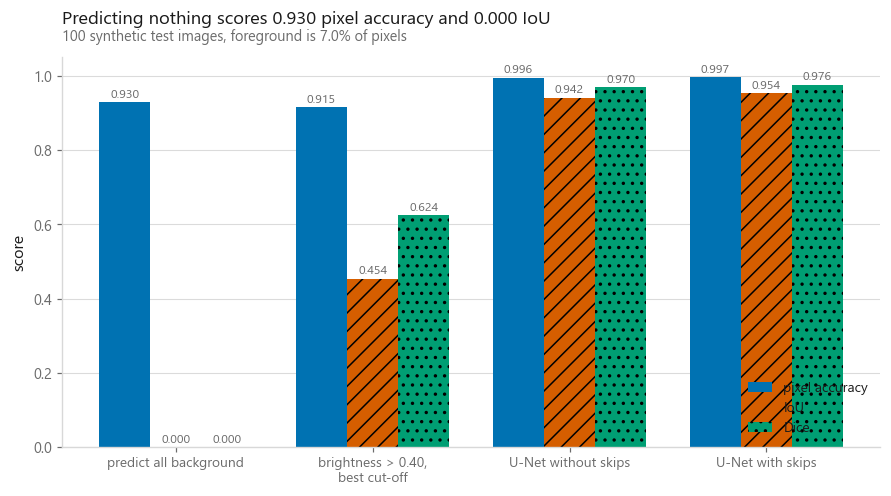

In [9]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
metrics = ["pixel accuracy", "IoU", "Dice"]
positions = np.arange(len(table))
bar_width = 0.26

for i, metric in enumerate(metrics):
    ax.bar(positions + (i - 1) * bar_width, table[metric], width=bar_width,
           color=[style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[2]][i],
           label=metric)
    for x_position, value in zip(positions + (i - 1) * bar_width, table[metric]):
        ax.annotate(f"{value:.3f}", xy=(x_position, value), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=8, color=style.MUTED)

for bar, hatch in zip(ax.patches, [""] * len(table) + ["//"] * len(table) + [".."] * len(table)):
    bar.set_hatch(hatch)

ax.set_xticks(positions, [name.replace(", ", ",\n") for name in table["model"]], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.legend(loc="lower right", fontsize=9)
style.title(
    ax,
    f"Predicting nothing scores {table['pixel accuracy'].iloc[0]:.3f} pixel accuracy "
    f"and {table['IoU'].iloc[0]:.3f} IoU",
    f"{len(x_test)} synthetic test images, foreground is {foreground_test:.1%} of pixels")
style.save(fig, FIG / "fig-02-metrics-disagree.png")

### Sweeping the decision threshold

The model outputs a probability per pixel and 0.5 is a convention, not a result.
Sweeping it separates the two metrics again: moving the threshold trades false
positives against false negatives, which IoU and Dice feel directly and pixel
accuracy barely notices, because both kinds of error are rare compared with the
background it is busy getting right.

In [10]:
THRESHOLDS = np.linspace(0.05, 0.95, 19)
sweep_rows = []
for threshold in THRESHOLDS:
    prediction = probabilities_skips.numpy() > threshold
    sweep_rows.append({"threshold": float(threshold),
                       "pixel accuracy": pixel_accuracy(prediction, truth),
                       "IoU": iou(prediction, truth),
                       "Dice": dice(prediction, truth)})

sweep = pd.DataFrame(sweep_rows)
best_threshold = float(sweep.loc[sweep["IoU"].idxmax(), "threshold"])
print(sweep.to_string(index=False, float_format="{:.4f}".format))
print(f"\nbest IoU at threshold {best_threshold:.2f}: {sweep['IoU'].max():.4f}, "
      f"against {sweep.loc[sweep['threshold'].sub(0.5).abs().idxmin(), 'IoU']:.4f} at 0.50")
print(f"range across the sweep: pixel accuracy "
      f"{sweep['pixel accuracy'].max() - sweep['pixel accuracy'].min():.4f}, "
      f"IoU {sweep['IoU'].max() - sweep['IoU'].min():.4f}")

 threshold  pixel accuracy    IoU   Dice
    0.0500          0.9933 0.9125 0.9543
    0.1000          0.9947 0.9295 0.9635
    0.1500          0.9952 0.9360 0.9669
    0.2000          0.9956 0.9405 0.9693
    0.2500          0.9959 0.9444 0.9714
    0.3000          0.9961 0.9465 0.9725
    0.3500          0.9963 0.9491 0.9739
    0.4000          0.9964 0.9510 0.9749
    0.4500          0.9965 0.9524 0.9756
    0.5000          0.9967 0.9540 0.9765
    0.5500          0.9968 0.9552 0.9771
    0.6000          0.9968 0.9558 0.9774
    0.6500          0.9969 0.9566 0.9778
    0.7000          0.9969 0.9570 0.9780
    0.7500          0.9970 0.9574 0.9782
    0.8000          0.9970 0.9577 0.9784
    0.8500          0.9968 0.9553 0.9771
    0.9000          0.9965 0.9510 0.9749
    0.9500          0.9955 0.9358 0.9669

best IoU at threshold 0.80: 0.9577, against 0.9540 at 0.50
range across the sweep: pixel accuracy 0.0037, IoU 0.0451


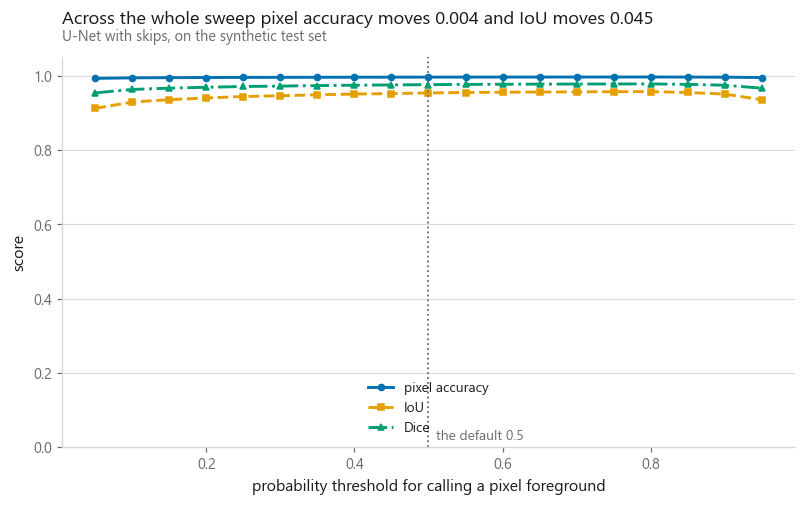

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
for i, metric in enumerate(["pixel accuracy", "IoU", "Dice"]):
    ax.plot(sweep["threshold"], sweep[metric], color=style.PALETTE[i],
            ls=style.DASHES[i], marker=style.MARKERS[i], markersize=4, label=metric)

ax.axvline(0.5, color=style.MUTED, ls=":", lw=1.2)
ax.annotate("the default 0.5", xy=(0.5, 0.02), xytext=(5, 0), textcoords="offset points",
            fontsize=9, color=style.MUTED)
ax.set_xlabel("probability threshold for calling a pixel foreground")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower center", fontsize=9)
style.title(
    ax,
    f"Across the whole sweep pixel accuracy moves "
    f"{sweep['pixel accuracy'].max() - sweep['pixel accuracy'].min():.3f} and IoU moves "
    f"{sweep['IoU'].max() - sweep['IoU'].min():.3f}",
    "U-Net with skips, on the synthetic test set")
style.save(fig, FIG / "fig-03-threshold-sweep.png")

### What the skip connections did

Same parameters, same seed, same data, same number of epochs. The only
difference is whether the decoder receives the encoder's feature maps or a block
of zeros. Two columns are worth reading separately: IoU over the whole image,
and IoU restricted to the boundary band, where the localisation the skips carry
should show up if it shows up anywhere.

Two aggregate numbers from two runs are not enough to rank anything, so the cell
also scores every test image on its own and pairs them. That costs nothing,
because both models have already made their predictions, and it turns "the skips
scored higher" into a statement with an error bar on it.

In [12]:
comparison = pd.DataFrame([
    {"network": "without skips",
     "IoU": iou(probabilities_plain.numpy() > 0.5, truth),
     "boundary-band IoU": iou(probabilities_plain.numpy()[band.numpy()] > 0.5,
                              truth[band.numpy()]),
     "seconds to train": seconds_plain},
    {"network": "with skips",
     "IoU": iou(probabilities_skips.numpy() > 0.5, truth),
     "boundary-band IoU": iou(probabilities_skips.numpy()[band.numpy()] > 0.5,
                              truth[band.numpy()]),
     "seconds to train": seconds_skips},
])
comparison["parameters"] = [count(UNet(use_skips=False)), count(UNet(use_skips=True))]

print(comparison.to_string(index=False, formatters={
    "IoU": "{:.4f}".format, "boundary-band IoU": "{:.4f}".format,
    "seconds to train": "{:.0f}".format, "parameters": "{:,}".format,
}))

whole_gain = comparison["IoU"].iloc[1] - comparison["IoU"].iloc[0]
band_gain = comparison["boundary-band IoU"].iloc[1] - comparison["boundary-band IoU"].iloc[0]
print(f"\nskips were worth {whole_gain:+.4f} IoU over the whole image "
      f"and {band_gain:+.4f} IoU inside the boundary band")

# Two aggregate numbers from two runs cannot say whether that gap is real. The
# cheapest scale for the noise is already sitting in the predictions: score each
# test image separately, pair them up, and look at how much the difference moves
# from image to image. No retraining, and it is the difference between "the skips
# won" and "the skips won on this test set".
per_image = np.array([
    iou(probabilities_skips.numpy()[i] > 0.5, truth[i])
    - iou(probabilities_plain.numpy()[i] > 0.5, truth[i])
    for i in range(len(truth))
])
paired_mean = per_image.mean()
paired_se = per_image.std(ddof=1) / np.sqrt(len(per_image))
skips_won = int((per_image > 0).sum())

print(f"\nper-image IoU difference over all {len(per_image)} test images")
print(f"  mean {paired_mean:+.4f}, standard error {paired_se:.4f}, "
      f"{paired_mean / paired_se:.1f} standard errors from zero")
print(f"  skips ahead on {skips_won} images, behind on "
      f"{len(per_image) - skips_won}, range {per_image.min():+.3f} "
      f"to {per_image.max():+.3f}")

if abs(paired_mean) < 2 * paired_se:
    skip_verdict = (f"one pair of runs cannot separate these two networks: "
                    f"{paired_mean:+.4f} mean IoU with a standard error of "
                    f"{paired_se:.4f}")
elif band_gain > whole_gain:
    skip_verdict = ("the skips helped more at the boundaries than over the image as a "
                    "whole, which is where the argument says they should")
elif whole_gain > 0:
    skip_verdict = ("the skips helped overall but not more at the boundaries than "
                    "elsewhere in this run")
else:
    skip_verdict = ("the skips did not help at all here, at this size and this number "
                    "of epochs")
print(f"verdict: {skip_verdict}")

      network    IoU boundary-band IoU seconds to train parameters
without skips 0.9419            0.9018                9    117,073
   with skips 0.9540            0.9349                8    117,073

skips were worth +0.0121 IoU over the whole image and +0.0331 IoU inside the boundary band

per-image IoU difference over all 100 test images
  mean +0.0176, standard error 0.0052, 3.4 standard errors from zero
  skips ahead on 81 images, behind on 19, range -0.262 to +0.142
verdict: the skips helped more at the boundaries than over the image as a whole, which is where the argument says they should


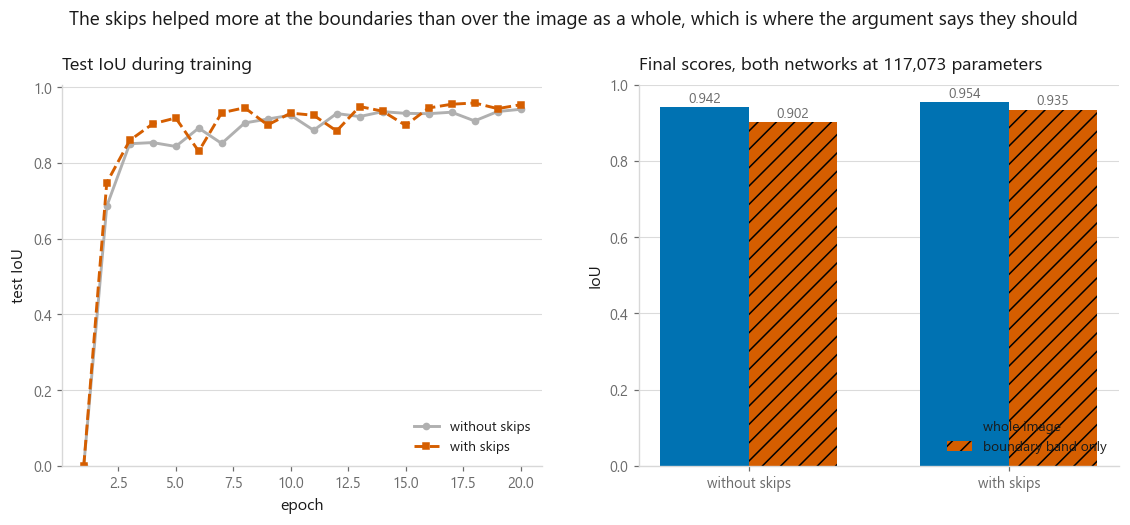

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.5))

for i, (label, history) in enumerate([("without skips", history_plain),
                                      ("with skips", history_skips)]):
    axes[0].plot(history["epoch"], history["test IoU"],
                 color=[style.NEUTRAL, style.HIGHLIGHT][i], ls=style.DASHES[i],
                 marker=style.MARKERS[i], markersize=4, label=label)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("test IoU")
axes[0].set_ylim(0, None)
axes[0].legend(loc="lower right", fontsize=9)
style.title(axes[0], "Test IoU during training")

positions = np.arange(2)
width = 0.34
axes[1].bar(positions - width / 2, comparison["IoU"], width=width,
            color=style.PALETTE[0], label="whole image")
axes[1].bar(positions + width / 2, comparison["boundary-band IoU"], width=width,
            color=style.HIGHLIGHT, label="boundary band only")
for bar in axes[1].patches[2:]:
    bar.set_hatch("//")
for bar in axes[1].patches:
    axes[1].annotate(f"{bar.get_height():.3f}",
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha="center",
                     fontsize=9, color=style.MUTED)
axes[1].set_xticks(positions, comparison["network"])
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("IoU")
axes[1].legend(loc="lower right", fontsize=9)
style.title(axes[1], f"Final scores, both networks at "
                     f"{count(UNet(use_skips=True)):,} parameters")

fig.suptitle(skip_verdict[0].upper() + skip_verdict[1:],
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-skips-or-not.png")

Read the count of images each network won before reading the means. Two
aggregate IoU numbers hide the fact that the per-image differences have both
signs in them, and the number of test images the skips lost on is the quickest
way to see how far this is from a clean sweep.

The boundary-band column is the one carrying the theory. If skips do what the
architecture says they do, hand position information from the encoder to a
decoder that pooled it away, then the gain should concentrate where position is
in doubt, which is the edge of a shape and not its interior. The interior is
easy for both networks: it is far from any boundary, so a coarse feature map
already gets it right. That is why an overall IoU gain understates the effect
and a boundary-band gain is the measurement to quote.

What I would not do is turn either number into a rule about skip connections.
One pair of runs on 64x64 synthetic shapes cannot rank two architectures, and
the last section of this notebook says what it would take to.

### Looking at the predictions

Metrics compress a 64x64 disagreement into one number, and the disagreement has
structure a number cannot show. The rows below are the image, the true mask, and
each model's mask, on the same four test images. Watch for the image where the
network without skips is the better of the two, because it is a reminder that
the aggregate is a mean over cases that disagree.

per-image IoU on the four shown, with skips then without:
  image 0: 0.964  0.950
  image 1: 1.000  0.973
  image 2: 1.000  0.967
  image 3: 0.955  0.969


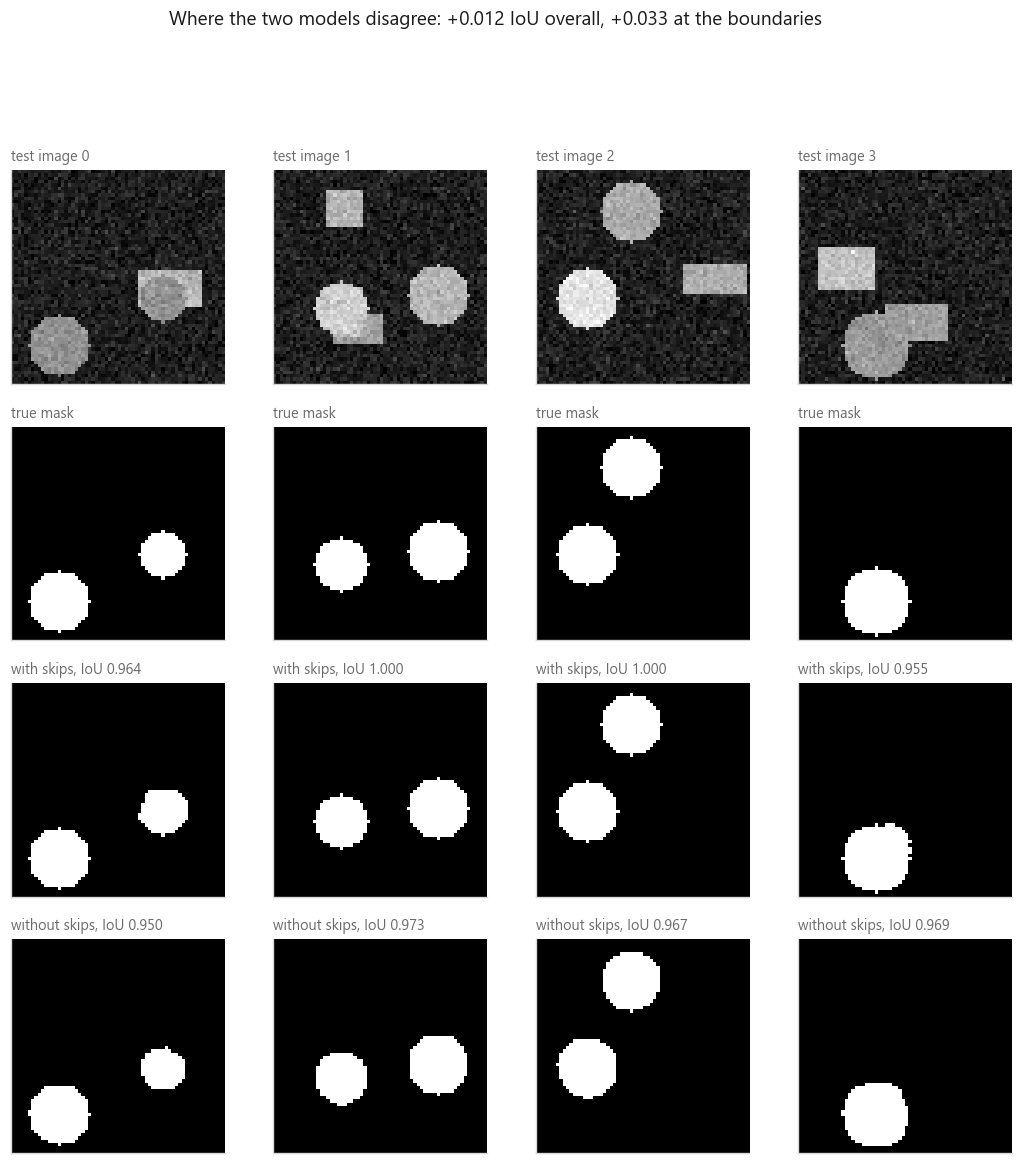

In [14]:
SHOW = [0, 1, 2, 3]
panels = [("image", x_test, "gray"),
          ("true mask", m_test, "gray"),
          ("with skips", (probabilities_skips > 0.5).float(), "gray"),
          ("without skips", (probabilities_plain > 0.5).float(), "gray")]

fig, axes = plt.subplots(len(panels), len(SHOW), figsize=(11.8, 11.6))
for row, (label, source, cmap) in enumerate(panels):
    for column, index in enumerate(SHOW):
        ax = axes[row, column]
        ax.imshow(source[index, 0], cmap=cmap, vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if row == 0:
            ax.set_title(f"test image {index}", fontsize=9.5, color=style.MUTED, loc="left")
        if row > 0 and label != "true mask":
            per_image = iou(source[index, 0].numpy() > 0.5, truth[index, 0])
            ax.set_title(f"{label}, IoU {per_image:.3f}", fontsize=9.5,
                         color=style.MUTED, loc="left")
        elif row > 0:
            ax.set_title(label, fontsize=9.5, color=style.MUTED, loc="left")

fig.suptitle(f"Where the two models disagree: {whole_gain:+.3f} IoU overall, "
             f"{band_gain:+.3f} at the boundaries",
             x=0.5, y=1.005, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-predictions.png")

print("per-image IoU on the four shown, with skips then without:")
for index in SHOW:
    print(f"  image {index}: "
          f"{iou(probabilities_skips[index, 0].numpy() > 0.5, truth[index, 0]):.3f}  "
          f"{iou(probabilities_plain[index, 0].numpy() > 0.5, truth[index, 0]):.3f}")

In [15]:
print(f"whole notebook: {(time.perf_counter() - NOTEBOOK_STARTED) / 60:.1f} minutes on {device}")

whole notebook: 0.4 minutes on cuda


### What this experiment does not settle

One seed, one small synthetic dataset, one architecture size, twenty epochs. The
skip-connection comparison is a single pair of runs, and the numbers above are
what those two runs produced rather than an estimate of what they would produce
on average. A serious version repeats each configuration over several seeds and
reports the spread, which costs several times the runtime this notebook has.

The task is also easier than any real one. The masks are exact, the shapes are
drawn from two families I chose, and there is no ambiguity about where a
boundary is. That is deliberate, because it makes the metric arguments in
section 3 unarguable, and it is also the reason no number here transfers to a
real segmentation problem.

## Cheat sheet

| | |
|---|---|
| **The task** | One label per pixel. Output is an image, not a vector |
| **Never report** | Pixel accuracy on an imbalanced mask. The do-nothing baseline in section 5 is why |
| **Report instead** | IoU, and Dice if you must. They are monotone in each other, so reporting both adds nothing |
| **Dice against IoU** | `Dice = 2*IoU / (1 + IoU)`, so Dice is always the larger number |
| **Architecture** | Encoder halves resolution and doubles channels, decoder reverses it, skips carry the missing position information across |
| **Loss** | Per-pixel binary cross entropy to start. Dice loss or a weighted version when the foreground is very small |
| **Threshold** | 0.5 is a convention. Sweep it on validation data and keep the best, as in section 5 |
| **Boundaries** | Score inside a band around the true edge when boundary quality is what you care about |
| **Watch out** | A model can score well on IoU and still be useless if the errors all fall on one class of object. Look at the masks |

## What to remember

1. Pixel accuracy measures the class prior when the foreground is small. The
   all-background baseline in section 5 prints exactly how well doing nothing does.
2. IoU and Dice drop the true negatives, which is why they notice an empty
   prediction and why they respond to a two-pixel shift of a correct mask.
   Reporting both adds nothing, since one is a function of the other.
3. The bottleneck knows what, the early encoder maps know where, and the skips
   connect them. That predicts the gain should concentrate at boundaries rather
   than spread over the image, which is why the boundary band is worth scoring.
4. When you compare two architectures, make them the same size first. Zeros in
   place of the encoder features keep the parameter count identical, so the
   comparison is about information rather than capacity, and cutting the
   concatenation instead would have confounded the two.
5. Two aggregate scores from two runs cannot rank two networks. Scoring each
   test image separately costs nothing and gives you a standard error, and here
   it also shows the per-image differences carrying both signs.
6. The decision threshold is a free parameter that moves IoU far more than it
   moves pixel accuracy. Sweep it, and sweep it on data you did not train on,
   because the best threshold here was nowhere near the default.

Segmentation labels every pixel and never says how many objects there are.
[08-07 Object detection](../07-object-detection/) is the other half of that
answer, and it has the opposite metric problem.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-07 Object detection, an introduction](../07-object-detection/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#ImageSegmentation` `#UNet` `#ComputerVision` `#PyTorch`
`#IoU` `#DiceCoefficient` `#MachineLearning` `#MLTutorial` `#AI`